In [88]:
# import öncesinde terminalde çalıştırılan kodlar:
# env simocuk olarak seçtik.
# conda install -n simocuk pip --force-reinstall -y ,, "simocuk ortamındaki pip'i internetten sıfır ve sağlam haliyle indirip üzerine yaz"
# conda activate simocuk
# /Users/simonxji/anaconda3/envs/simocuk/bin/python -m pip install joblib pandas seaborn matplotlib scikit-learn scikit-uplift catboost lightgbm xgboost

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from catboost import CatBoostClassifier
from sklearn.linear_model import RidgeClassifier
from sklift.models import SoloModel
from sklift.metrics import qini_auc_score
from sklift.metrics import qini_curve, qini_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [147]:
def load_application_train():
    data = pd.read_csv("/Users/simonxji/Desktop/miuul dsb final project/causal-crm-uplift-modeling/hillstrom_kampanya_verisi.csv")
    return data

df = load_application_train()
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,target,treatment
0,10,2) $100 - $200,142.440,1,0,Surburban,0,Phone,0,Womens E-Mail
1,6,3) $200 - $350,329.080,1,1,Rural,1,Web,0,No E-Mail
2,7,2) $100 - $200,180.650,0,1,Surburban,1,Web,0,Womens E-Mail
3,9,5) $500 - $750,675.830,1,0,Rural,1,Web,0,Mens E-Mail
4,2,1) $0 - $100,45.340,1,0,Urban,0,Web,0,Womens E-Mail


In [148]:

def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print()
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}), end="\n\n\n")

def correlation_matrix(df, cols):
    fig = plt.gcf()
    fig.set_size_inches(10, 8)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    fig = sns.heatmap(df[cols].corr(), annot=True, linewidths=0.5, annot_kws={'size': 12}, linecolor='w', cmap='RdBu')
    plt.show(block=True)

               treatment  Ratio
treatment                      
Womens E-Mail      21387 33.417
Mens E-Mail        21307 33.292
No E-Mail          21306 33.291



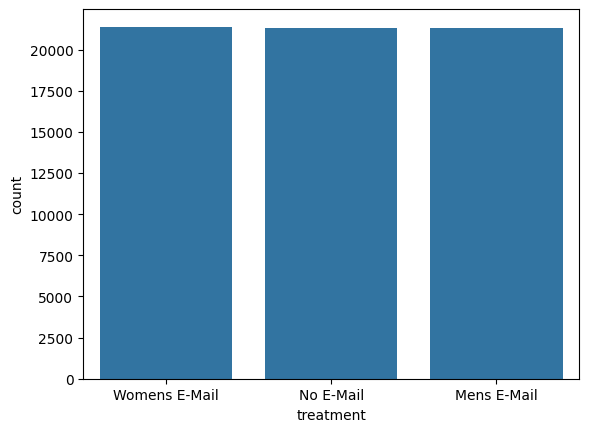

count   64000.000
mean      242.086
std       256.159
min        29.990
5%         29.990
10%        29.990
20%        50.298
30%        80.187
40%       115.280
50%       158.110
60%       210.810
70%       281.210
80%       382.032
90%       561.194
95%       747.262
99%      1218.664
max      3345.930
Name: history, dtype: float64


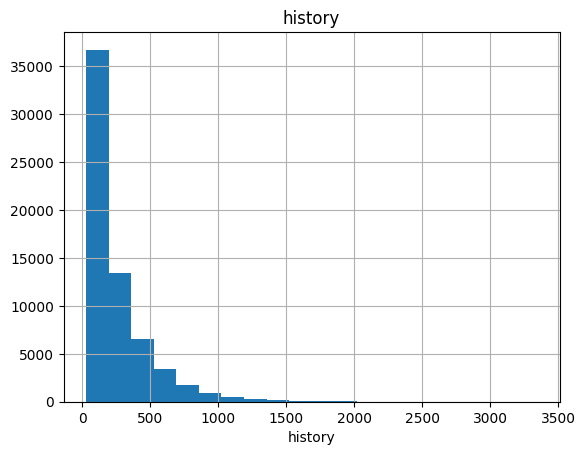

In [149]:
cat_summary(df, "treatment", plot=True)

num_summary(df, "history", plot=True)

In [150]:
target_summary_with_num(df, "target", "history")
target_summary_with_cat(df, "target", "channel") # bunu sunuma koy??

        history
target         
0       235.163
1       282.324


              TARGET_MEAN
channel                  
Multichannel        0.172
Phone               0.127
Web                 0.159




In [151]:
df.isnull().values.any()

np.False_

In [152]:
df.head()

# RFM (recency, frequency, monetary (history olarak adlandırılmış))
# history_segment, history'nin gruplanmış hali. sadece birini kullanmak yeterli. ikisi beraber yüksek korelasyon.
# sadece kadın veya sadece erkek ürünü alan kişiler de var. her bir index bir kişiyi temsil eder.
# newbie yeni üye olup olmadığı.
# channel, müşterinin geçmişte alışveriş yaparken hangi kanalı kullandığı
# treatment, müşteriye kadın/erkek emaili mi atıldı ya da hiç email atılmadı mı?
# target, e-posta atıldıktan sonraki 2 hafta içinde bu müşteri siteden alışveriş yaptı mı? tahmin etmeye çalıştığımız değer

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,target,treatment
0,10,2) $100 - $200,142.440,1,0,Surburban,0,Phone,0,Womens E-Mail
1,6,3) $200 - $350,329.080,1,1,Rural,1,Web,0,No E-Mail
2,7,2) $100 - $200,180.650,0,1,Surburban,1,Web,0,Womens E-Mail
3,9,5) $500 - $750,675.830,1,0,Rural,1,Web,0,Mens E-Mail
4,2,1) $0 - $100,45.340,1,0,Urban,0,Web,0,Womens E-Mail


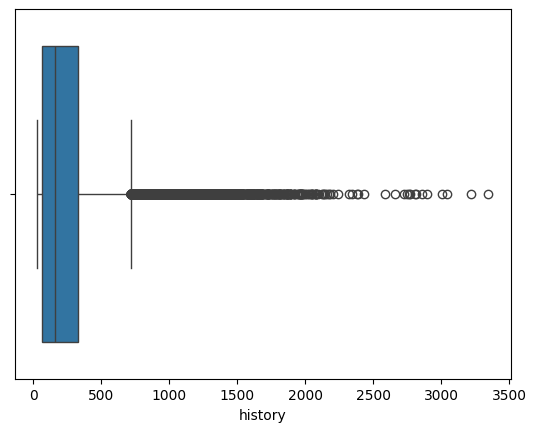

,count,mean,std,min,25%,50%,75%,max
recency,64000.000,5.764,3.508,1.000,2.000,6.000,9.000,12.000
history,64000.000,242.086,256.159,29.990,64.660,158.110,325.657,3345.930
mens,64000.000,0.551,0.497,0.000,0.000,1.000,1.000,1.000
womens,64000.000,0.550,0.498,0.000,0.000,1.000,1.000,1.000
newbie,64000.000,0.502,0.500,0.000,0.000,1.000,1.000,1.000
target,64000.000,0.147,0.354,0.000,0.000,0.000,0.000,1.000


In [153]:
sns.boxplot(x=df["history"])
plt.show() 

df.describe().T
# standart sapmanın ortalamadan büyük olması yüksek varyans yani verinin düzensizliği demektir.

In [156]:

def outlier_thresholds(dataframe, col_name, q1=0.01, q3=0.99):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

check_outlier(df, "history")


False

In [155]:
def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

grab_outliers(df, "history", True) 
# sadece iki müşteri var ama harcamaları aşırı yüksek. bu kişileri direkt silersek değerli bir içgörü kaybolur.
# bunlara Whale denir. Sayıları çok azdır ama şirketin toplam cirosunun çok büyük bir kısmını tek başlarına sırtlarlar. 
# Bu insanların hangi kanalı kullandığı veya e-postalara nasıl tepki verdiği (target) şirket için altın değerindedir.

def replace_with_thresholds(dataframe, variable): # bunun yerine logaritmik dönüşüm de yapılabilir.
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

replace_with_thresholds(df, "history")



       recency history_segment  history  mens  womens   zip_code  newbie       channel  target      treatment
4579         2     7) $1,000 + 3345.930     1       1  Surburban       1         Phone       0      No E-Mail
38680        1     7) $1,000 + 3215.970     1       1      Urban       1  Multichannel       1    Mens E-Mail
43060        1     7) $1,000 + 3003.480     1       1      Urban       1         Phone       0      No E-Mail
52860        1     7) $1,000 + 3040.200     0       1      Urban       1           Web       0  Womens E-Mail


In [157]:
df.describe().T # max history değerimiz az da olsa düştü. çok düşerse gerçekliği yitirir.

,count,mean,std,min,25%,50%,75%,max
recency,64000.000,5.764,3.508,1.000,2.000,6.000,9.000,12.000
history,64000.000,242.076,256.053,29.990,64.660,158.110,325.657,3001.676
mens,64000.000,0.551,0.497,0.000,0.000,1.000,1.000,1.000
womens,64000.000,0.550,0.498,0.000,0.000,1.000,1.000,1.000
newbie,64000.000,0.502,0.500,0.000,0.000,1.000,1.000,1.000
target,64000.000,0.147,0.354,0.000,0.000,0.000,0.000,1.000


target
0   0.853
1   0.147
Name: proportion, dtype: float64


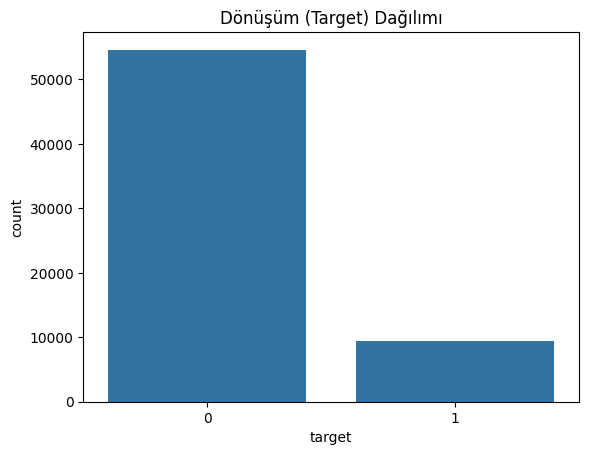

In [158]:
# Satın alma oranlarını yüzdesel olarak görelim
print(df['target'].value_counts(normalize=True))

sns.countplot(data=df, x='target')
plt.title("Dönüşüm (Target) Dağılımı")
plt.show()

In [159]:
# Gruplardaki insan sayıları
print(df['treatment'].value_counts())
print()
# Grupların yüzdesel oranları (A/B testi mantığı gereği %33 - %33 - %33 civarı çıkmalı)
print(df['treatment'].value_counts(normalize=True))

treatment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

treatment
Womens E-Mail   0.334
Mens E-Mail     0.333
No E-Mail       0.333
Name: proportion, dtype: float64


channel
Multichannel   0.172
Phone          0.127
Web            0.159
Name: target, dtype: float64

zip_code
Rural       0.188
Surburban   0.140
Urban       0.139
Name: target, dtype: float64

            count    mean     std    min    25%     50%     75%      max
history 64000.000 242.076 256.053 29.990 64.660 158.110 325.657 3001.676
recency 64000.000   5.764   3.508  1.000  2.000   6.000   9.000   12.000


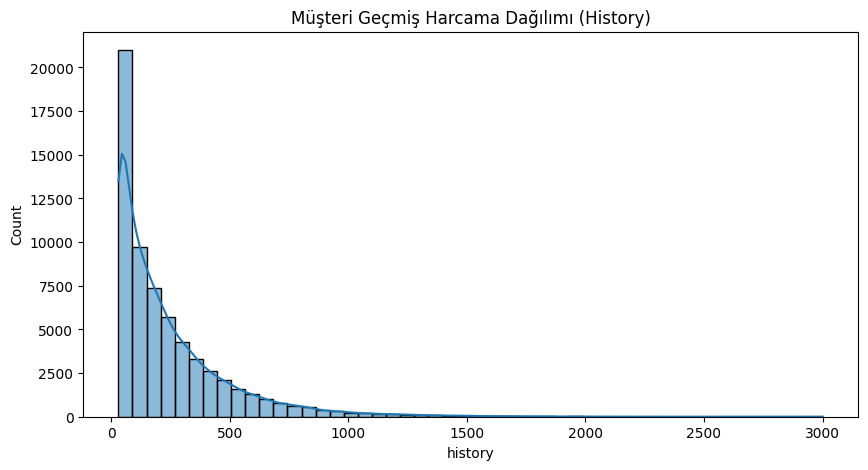

In [160]:
# Hangi alışveriş kanalını kullananların satın alma oranı daha yüksek?
print(df.groupby('channel')['target'].mean())
print()
# Hangi bölgede yaşayanların satın alma oranı daha yüksek?
print(df.groupby('zip_code')['target'].mean())
print()
# Sayısal sütunların genel istatistikleri
print(df[['history', 'recency']].describe().T)

# History sütununun dağılım grafiği - sağa çarpıklığı çıplak gözle göreceksin, yön tayini yapılırken tepe noktasına değil, kuyruğun uzadığı tarafa bakılır.
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='history', kde=True, bins=50)
plt.title("Müşteri Geçmiş Harcama Dağılımı (History)")
plt.show()

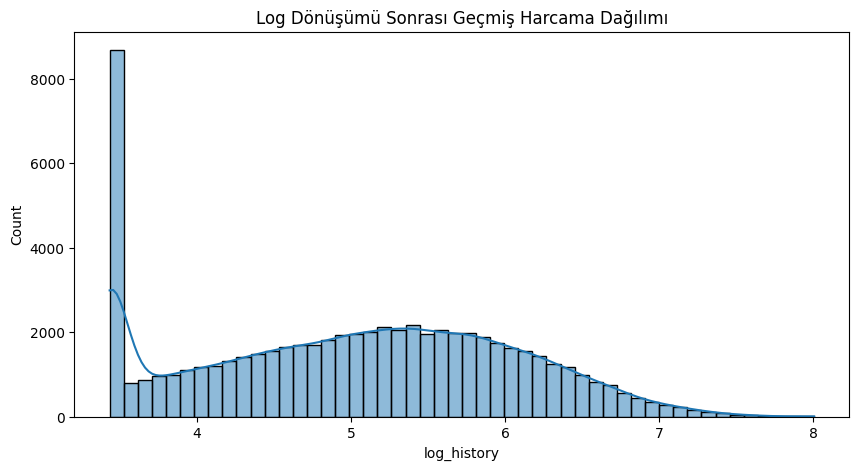

In [161]:
df['log_history'] = np.log1p(df['history']) #right-skewness'ı çözmek için. ridge bundan hoşlanmaz.

# Yeni dağılıma tekrar bakalım
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='log_history', kde=True, bins=50)
plt.title("Log Dönüşümü Sonrası Geçmiş Harcama Dağılımı")
plt.show()


In [172]:
df.drop(columns=['history_segment'], errors='ignore', inplace=True)

In [173]:
df.head()

,recency,history,mens,womens,newbie,target,treatment,log_history,spending_intensity,is_unisex_buyer,digital_newbies,digital_veterans,urban_web_user,history_segment_2) $100 - $200,history_segment_3) $200 - $350,history_segment_4) $350 - $500,history_segment_5) $500 - $750,"history_segment_6) $750 - $1,000","history_segment_7) $1,000 +",zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,10,142.440,1,0,0,0,Womens E-Mail,4.966,12.949,0,0,0,0,1,0,0,0,0,0,1,0,1,0
1,6,329.080,1,1,1,0,No E-Mail,5.799,47.011,1,1,0,0,0,1,0,0,0,0,0,0,0,1
2,7,180.650,0,1,1,0,Womens E-Mail,5.202,22.581,0,1,0,0,1,0,0,0,0,0,1,0,0,1
3,9,675.830,1,0,1,0,Mens E-Mail,6.517,67.583,0,1,0,0,0,0,0,1,0,0,0,0,0,1
4,2,45.340,1,0,0,0,Womens E-Mail,3.836,15.113,0,0,1,1,0,0,0,0,0,0,0,1,0,1


In [ ]:
# A. Harcama Yoğunluğu, taze olanın sadakati daha yüksek.
df['spending_intensity'] = df['history'] / (df['recency'] + 1)

# B. Kategori Çeşitliliği, kampanya e-postalarına tepkisi tek bir kategoriye bakan kişiden çok farklı olur.
df['is_unisex_buyer'] = df['mens'] * df['womens']

# C. Dijital Segmentler, kampanyasının etkisini (uplift) hesaplarken eski dijitallerle yeni dijitalleri farklı skorlar vererek ikna etmeye çalışıyor.
df['digital_newbies'] = df['newbie'] * (df['channel'] == 'Web').astype(int)
df['digital_veterans'] = (1 - df['newbie']) * (df['channel'] == 'Web').astype(int)

# D. Şehir merkezinde yaşayıp web kullanan kitle, e-postalara anında reaksiyon göstermeye en müsait olan "hızlı tüketici" segmentidir.
df['urban_web_user'] = ((df['zip_code'] == 'Urban') & (df['channel'] == 'Web')).astype(int)

KeyError: 'channel'

In [176]:
df.head()

,recency,history,mens,womens,newbie,target,treatment,log_history,spending_intensity,is_unisex_buyer,digital_newbies,digital_veterans,urban_web_user,history_segment_2) $100 - $200,history_segment_3) $200 - $350,history_segment_4) $350 - $500,history_segment_5) $500 - $750,"history_segment_6) $750 - $1,000","history_segment_7) $1,000 +",zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,10,142.440,1,0,0,0,Womens E-Mail,4.966,12.949,0,0,0,0,1,0,0,0,0,0,1,0,1,0
1,6,329.080,1,1,1,0,No E-Mail,5.799,47.011,1,1,0,0,0,1,0,0,0,0,0,0,0,1
2,7,180.650,0,1,1,0,Womens E-Mail,5.202,22.581,0,1,0,0,1,0,0,0,0,0,1,0,0,1
3,9,675.830,1,0,1,0,Mens E-Mail,6.517,67.583,0,1,0,0,0,0,0,1,0,0,0,0,0,1
4,2,45.340,1,0,0,0,Womens E-Mail,3.836,15.113,0,0,1,1,0,0,0,0,0,0,0,1,0,1


In [165]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first, dtype=int) # drop_first=True, veri setin gereksiz yere şişmez, multicollinearity engeller
    return dataframe

ohe_cols = [col for col in df.columns if (df[col].dtype == 'O' or df[col].dtype.name == 'category') 
            and col not in ['target', 'treatment'] and 10 >= df[col].nunique() > 1]

df = one_hot_encoder(df, ohe_cols) 

# Gördüğün gibi, model ilk 4 kolonun değerini bildiği an, 5. kolonun ne olacağını (oraya bakmasına bile gerek kalmadan) matematiksel olarak %100 doğrulukla bulabilir. İşte bu durum mükemmel çoklu doğrusal bağlantıdır.
# Sen drop_first=False yaptığında, elindeki 5 kolonun toplamı (1) ile Intercept kolonunun kendisi (1) tamamen üst üste biner. Lineer cebirde buna bağımlı matris denir.

In [166]:
df.head()

,recency,history,mens,womens,newbie,target,treatment,log_history,spending_intensity,is_unisex_buyer,digital_newbies,digital_veterans,urban_web_user,history_segment_2) $100 - $200,history_segment_3) $200 - $350,history_segment_4) $350 - $500,history_segment_5) $500 - $750,"history_segment_6) $750 - $1,000","history_segment_7) $1,000 +",zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,10,142.440,1,0,0,0,Womens E-Mail,4.966,12.949,0,0,0,0,1,0,0,0,0,0,1,0,1,0
1,6,329.080,1,1,1,0,No E-Mail,5.799,47.011,1,1,0,0,0,1,0,0,0,0,0,0,0,1
2,7,180.650,0,1,1,0,Womens E-Mail,5.202,22.581,0,1,0,0,1,0,0,0,0,0,1,0,0,1
3,9,675.830,1,0,1,0,Mens E-Mail,6.517,67.583,0,1,0,0,0,0,0,1,0,0,0,0,0,1
4,2,45.340,1,0,0,0,Womens E-Mail,3.836,15.113,0,0,1,1,0,0,0,0,0,0,0,1,0,1


In [ ]:
df['treatment'] = np.where(df['treatment'] == 'No E-mail', 0, 1)

In [ ]:
df.head()

In [143]:
df_train, df_test = train_test_split(
    df, 
    test_size=0.30, 
    random_state=17, 
    stratify=df['target'] # veri dengesiz olduğu için gerekli! dengeli olarak dağıtır. alışveriş yapan/toplam oranı aynıdır.
)

df_train.to_csv("train_data.csv", index=False)
df_test.to_csv("test_data.csv", index=False)

print(f"Eğitim Seti: {df_train.shape}")
print(f"Test Seti: {df_test.shape}")

Eğitim Seti: (44800, 17)
Test Seti: (19200, 17)


In [145]:
num_cols = ['history', 'recency', 'spending_intensity', 'log_history']

scaler = StandardScaler()

# Ortalama ve standart sapmayı sadece Train setinden öğrenip (fit_transform),
# Test setine sadece uyguluyoruz (transform).
df_train[num_cols] = scaler.fit_transform(df_train[num_cols])
df_test[num_cols] = scaler.transform(df_test[num_cols])

print(df_train[num_cols].head())

       history  recency  spending_intensity  log_history
36671    0.393   -1.355               1.133        0.816
24599   -0.716   -1.070              -0.418       -0.892
36611   -0.408   -0.500              -0.338       -0.072
179     -0.830   -1.070              -0.518       -1.545
30598   -0.220   -0.785              -0.145        0.219


In [146]:
X_train = df_train.drop(columns=['target', 'treatment'])
y_train = df_train['target']
treat_train = df_train['treatment'].values 

X_test = df_test.drop(columns=['target', 'treatment'])
y_test = df_test['target']
treat_test = df_test['treatment'].values

# GÜVENLİK KONTROLÜ
print("Benzersiz treatment değerleri (Train):", np.unique(treat_train))
print("Benzersiz treatment değerleri (Test):", np.unique(treat_test))
# Ekranda kesin olarak [0, 1] görmeliyiz!

print(f"Eğitim Matrisi Boyutu: {X_train.shape} | Test Matrisi Boyutu: {X_test.shape}")

Benzersiz treatment değerleri (Train): [1]
Benzersiz treatment değerleri (Test): [1]
Eğitim Matrisi Boyutu: (44800, 15) | Test Matrisi Boyutu: (19200, 15)


In [121]:


# 5-Katlı Çapraz Doğrulama Fonksiyonu
def uplift_cv_score(base_estimator, X, y, treatment):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        treat_tr, treat_val = treatment[train_idx], treatment[val_idx]
        
        # Modeli sarıp sadece bu fold için eğitiyoruz
        sm = SoloModel(base_estimator)
        sm.fit(X_tr, y_tr, treat_tr)
        
        # Validation tahmini ve Qini skoru
        preds = sm.predict(X_val)
        scores.append(qini_auc_score(y_true=y_val, uplift=preds, treatment=treat_val))
        
    return np.mean(scores)

# Modelleri Tanımlayalım (Ridge log_history'yi, CatBoost ham history'yi kullanacak)
print("--- 5-Fold Çapraz Doğrulama Skorları Hesaplanıyor ---")

cat_qini = uplift_cv_score(CatBoostClassifier(verbose=0, random_state=42), X_train, y_train, treat_train)
print(f"CatBoost Solo Model Ortalama Qini: {round(cat_qini, 4)}")

ridge_qini = uplift_cv_score(RidgeClassifier(random_state=42), X_train, y_train, treat_train)
print(f"Ridge Solo Model Ortalama Qini: {round(ridge_qini, 4)}")

--- 5-Fold Çapraz Doğrulama Skorları Hesaplanıyor ---


ValueError: operands could not be broadcast together with shapes (3,) (2,) 

In [ ]:
# final modeller tüm eğitim verisiyle eğitiliyor

# 1. Ağaç Tabanlı Modelin Eğitimi
final_cat_model = SoloModel(CatBoostClassifier(iterations=200, depth=6, verbose=0, random_state=42))
final_cat_model.fit(X_train, y_train, treat_train)

# 2. Doğrusal Modelin Eğitimi
final_ridge_model = SoloModel(RidgeClassifier(random_state=42))
final_ridge_model.fit(X_train, y_train, treat_train)

In [ ]:
print("--- TEST SETİ DEĞERLENDİRMESİ ---")

# 1. Test setindeki müşteriler için iki modelden de bağımsız tahminleri alıyoruz
cat_test_preds = final_cat_model.predict(X_test)
ridge_test_preds = final_ridge_model.predict(X_test)

# 2. ENSEMBLE SIRRI: Skorları harmanlıyoruz (%60 CatBoost ağırlığı, %40 Ridge ağırlığı)
ensemble_test_preds = (0.6 * cat_test_preds) + (0.4 * ridge_test_preds)

# 3. Nihai Başarı Skorunu Hesaplayalım
final_qini_score = qini_auc_score(y_true=y_test, uplift=ensemble_test_preds, treatment=treat_test)
print(f"🔥 Hibrit Ensemble Model Test Seti Qini Skoru: {round(final_qini_score, 4)}")

# 4. MATEMATİKSEL SİHİR: Qini Eğrisinin Koordinatlarını Hesaplama
# Bu fonksiyon bize x (popülasyon), y (bizim model) ve y_perfect (kusursuz teorik model) doğrularını verir
x_basis, y_model, y_perfect = qini_curve(y_true=y_test, uplift=ensemble_test_preds, treatment=treat_test)


# 5. SUNUM İÇİN PREMIUM "SWEET VIBES" QINI GRAFİĞİ ÇİZİMİ
plt.figure(figsize=(10, 6), facecolor='#FFF9F1') # Krem Arka Plan
ax = plt.axes()
ax.set_facecolor('#FFF9F1')

# A. Bizim Geliştirdiğimiz Akıllı Hibrit Model (Asil bir mor, kalın çizgi)
plt.plot(x_basis, y_model, label='CausalCRM (Ensemble Model)', color='#7C3AED', linewidth=2.5)

# B. Kusursuz Model (Teorik tavan çizgisi - Tatlı bir turuncu/amber, kesikli çizgi)
plt.plot(x_basis, y_perfect, label='Perfect Model (Theoretical)', color='#D97706', linestyle='--', linewidth=1.5)

# C. Rastgele Model (Hiçbir analitik model kullanmasaydık ne olurdu? Gri noktalı çizgi)
plt.plot([0, x_basis[-1]], [0, y_perfect[-1]], label='Random Baseline', color='#9CA3AF', linestyle=':')

# Grafiğin Estetik Ayarları
plt.title('CausalCRM - Final Ensemble Model Qini Curve (Test Set)', fontsize=14, fontweight='bold', color='#4A3728', pad=15)
plt.xlabel('Hedeflenen Müşteri Popülasyon Oranı (%)', color='#5F4B3B', fontsize=11)
plt.ylabel('Kümülatif Net Alışveriş Artışı (Kazanç)', color='#5F4B3B', fontsize=11)

# Lejant kutusunu krem ve mor çerçeveli yapalım
plt.legend(facecolor='#FFF9F1', edgecolor='#E9D5FF', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Çerçeve renklerini yumuşatalım
for spine in ax.spines.values():
    spine.set_color('#E9D5FF')

plt.tight_layout()
plt.show()